In [1]:
import pandas as pd
import seaborn as sns
import os
import warnings
import numpy as np

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rc

# set style
plt.style.use('seaborn-v0_8-paper')

# set sizes
SMALL_SIZE = 5
MEDIUM_SIZE = 6
BIGGER_SIZE = 7

rc('font', size=MEDIUM_SIZE)          # controls default text sizes
rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
rc('xtick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('ytick', labelsize=MEDIUM_SIZE)    # fontsize of the tick labels
rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

# set font
rc('font', **{'family':'serif','serif':['Arial']})
rc('svg', **{'fonttype':'none'})

# one more change to axes and tick widths
rc('axes', **{'linewidth': 0.5, 'labelpad': 2.5})

rc('xtick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})
rc('ytick', **{'major.width': 0.5, 'minor.width': 0.5, 'major.pad': 2.5})

In [19]:
def plot_results(df, statistic_functions, normalization, comparison, path_out_dir):

    # downsample for plotting
    df_return = df.sample(n=5000)
    
    counts_name_1 = 'ln(Mean) WT'
    
    for i_stat, statistic_function in enumerate(statistic_functions):

        if 'epsilon_diff' not in statistic_function:
            continue
        
        if f'valid_{statistic_function}' not in df_return:
            continue
        
        if 'zero_ratio' in statistic_function:
            df_return[f'valid_{statistic_function}'] = np.where(
                df_return[f'abs_value_{statistic_function}'] > df_return[f'ci_range_{statistic_function}'],
                'red',
                'blue'
            )
    
        path_bootstrap_dir_plot = os.path.join(path_out_dir, normalization)
            
        if 'norm10k' in statistic_function:
            path_bootstrap_dir_plot += '.normalized.gm10000'
            continue
        elif 'norm' in statistic_function:
            path_bootstrap_dir_plot += '.normalized.gmauto'
            continue
            
        path_bootstrap_dir_plot = os.path.join(path_bootstrap_dir_plot, comparison)
    
        os.makedirs(path_bootstrap_dir_plot, exist_ok=True)
        
        # some values might be inf, so drop these for plotting
        df_clean = df_return[[f'ci_range_{statistic_function}', f'value_{statistic_function}', 'xvalue', f'valid_{statistic_function}']].copy()
        df_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_clean.dropna(inplace=True)
        
        df_clean = df_clean.loc[df_clean['xvalue'] > 0]
        
        ci_ranges_clean = df_clean[f'ci_range_{statistic_function}']
        xvalues_clean = df_clean['xvalue']
        real_values_clean = df_clean[f'value_{statistic_function}']
        colors_clean = df_clean[f'valid_{statistic_function}']

        fig, ax = plt.subplots(figsize=(1,1))
    
        path_out_svg = os.path.join(path_bootstrap_dir_plot, f'{statistic_function}.svg')
        ax.scatter(np.log(xvalues_clean), real_values_clean, s=1, c=colors_clean)

        #if statistic_function == 'epsilon_diff':
        #    plt.plot([min(np.log(xvalues_clean)), max(np.log(xvalues_clean))], [0.02, 0.02], color='green')

        plt.ylim([-0.11, 0.41])
        plt.title(f'{normalization}')
        plt.xlabel(f'{counts_name_1}')
        plt.ylabel(f'{comparison}\n{statistic_function}')
        fig.savefig(path_out_svg)
        plt.show()
        

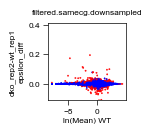

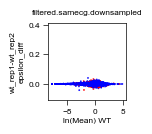

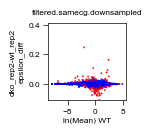

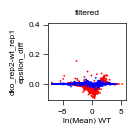

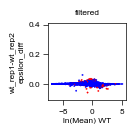

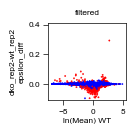

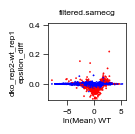

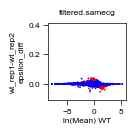

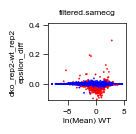

In [21]:
#path_dir = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_tko_downsampled_new/bootstrap'
path_dir = '/home/data/Shared/shared_datasets/sc_rna_seq/nlaszik/wt_dko_downsampled_rep2/bootstrap'

extension = 'bootstrapstats.csv'

stat_functions = [	
	'linear_diff_mean', 'lfc_mean', 'linear_diff_fano', 'lfc_fano', 'linear_diff_zero_ratio', 'lfc_zero_ratio', 'epsilon_diff',
	'linear_diff_mean_norm', 'lfc_mean_norm', 'linear_diff_fano_norm', 'lfc_fano_norm', 'linear_diff_zero_ratio_norm', 'lfc_zero_ratio_norm', 'epsilon_diff_norm',
	'linear_diff_mean_norm10k', 'lfc_mean_norm10k', 'linear_diff_fano_norm10k', 'lfc_fano_norm10k', 'linear_diff_zero_ratio_norm10k', 'lfc_zero_ratio_norm10k', 'epsilon_diff_norm10k',
]

found_files = []

for root, _, files in os.walk(path_dir):
    for file in files:
        if file.lower().endswith(extension.lower()):
            split_root = root.split('/')
            
            comparison = split_root[-1]
            normalization_method = split_root[-2]
            
            full_path = os.path.join(root, file)
            found_files.append({'path':full_path, 'comparison': comparison, 'normalization_method': normalization_method})

for fileset in found_files:

    df = pd.read_csv(fileset['path'])
    
    plot_results(df, stat_functions, fileset['normalization_method'], fileset['comparison'], 'figures')

    